# Join inspections to buildings and create polygons

In [1]:
import os
import sys

import contextily as ctx
import geopandas as gpd
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import ListedColormap
from shapely.geometry import box

sys.path.append("../utils")

import config

### Import subsetted SB buildings data

In [2]:
sb_buildings_path = os.path.join(
    config.data_dir, "microsoft_buildings", "sb_buildings.geojson"
)

buildings = gpd.read_file(sb_buildings_path)

### Check whether inspection points line up with buildings

#### Import inspections

In [3]:
config.cleaned_inspections_dir

'/capstone/wildfire_prep/data/inspections_data/cleaned_status'

In [4]:
# Function to read in inspections data for 2019-2023
def import_inspections_data(year):
    """
    Function to read in inspections data for a given year and convert to Albers CRS.
    """
    inspections = os.path.join(
        config.cleaned_inspections_dir, f"inspections_{year}.geojson"
    )
    inspections = gpd.read_file(inspections).to_crs(config.albers_crs)
    return inspections


# Read in inspection data for 2019-2023 as separate dataframes
inspections_dict = {}
for year in range(2019, 2024):
    inspections_dict[year] = import_inspections_data(year)

In [5]:
# Unpack from dictionary
inspections_2019 = inspections_dict[2019]
inspections_2020 = inspections_dict[2020]
inspections_2021 = inspections_dict[2021]
inspections_2022 = inspections_dict[2022]
inspections_2023 = inspections_dict[2023]

In [6]:
inspections_2019["inspection_id"]

0            1
1            2
2            3
3            4
4            5
         ...  
14670    14671
14671    14672
14672    14673
14673    14674
14674    14675
Name: inspection_id, Length: 14675, dtype: int32

#### Count number of inspections that fall outside of buildings

In [7]:
# Create a function that returns the number of inspections that fall outside building geometries for a given year
def inspections_within_buildings(year):
    """
    Function to return the number of inspections that fall within building geometries for a given year.
    """
    inspections = import_inspections_data(year)
    # Use left join to keep all inspections
    joined = inspections.sjoin(buildings, predicate="intersects", how="left")

    # Inspections within buildings have a non-null index_right
    intersects = joined[~joined["index_right"].isna()]
    # Inspections outside buildings have a null index_right
    outside = joined[joined["index_right"].isna()]

    return intersects.drop(columns=["index_right"]), outside.drop(
        columns=["index_right"]
    )


# For loop to print number of inspections that fall within and outside building geometries for each year
for year in range(2019, 2024):
    inspections_within, inspections_outside = inspections_within_buildings(year)
    print(
        f"{year} Inspections: \nWithin Buildings - {inspections_within.shape[0]} \nOutside of Buildings - {inspections_outside.shape[0]}\n"
    )

2019 Inspections: 
Within Buildings - 11011 
Outside of Buildings - 3664

2020 Inspections: 
Within Buildings - 9528 
Outside of Buildings - 2350

2021 Inspections: 
Within Buildings - 10491 
Outside of Buildings - 3521

2022 Inspections: 
Within Buildings - 10157 
Outside of Buildings - 3485

2023 Inspections: 
Within Buildings - 9919 
Outside of Buildings - 3454



#### Count number of non-compliant inspections that fall outside of buildings

In [8]:
# For loop to print number of non-compliant inspections that fall within and outside building geometries for each year
for year in range(2019, 2024):
    non_comp_inspections_in, non_comp_inspections_out = inspections_within_buildings(
        year
    )
    non_comp_inspections_in = non_comp_inspections_in[
        non_comp_inspections_in["status"] == "Non-Compliant"
    ]
    non_comp_inspections_out = non_comp_inspections_out[
        non_comp_inspections_out["status"] == "Non-Compliant"
    ]
    print(
        f"{year} Non-Compliant Inspections: \nWithin Buildings - {non_comp_inspections_in.shape[0]} \nOutside of Buildings - {non_comp_inspections_out.shape[0]}\n"
    )

2019 Non-Compliant Inspections: 
Within Buildings - 72 
Outside of Buildings - 51

2020 Non-Compliant Inspections: 
Within Buildings - 74 
Outside of Buildings - 20

2021 Non-Compliant Inspections: 
Within Buildings - 63 
Outside of Buildings - 7

2022 Non-Compliant Inspections: 
Within Buildings - 47 
Outside of Buildings - 13

2023 Non-Compliant Inspections: 
Within Buildings - 54 
Outside of Buildings - 17



## Assign inspections to nearby buildings

The minimum distance between buildings in CA is 10 feet (3.048 m). For this analysis, we will assign inspections to the closest building within 3 meters. 

In [9]:
# Assign inspections to buildings if the distance between them is < 3 meters
def assign_inspections_to_buildings(inspections, buildings, distance_threshold=3):
    """
    Function to assign inspections to buildings if the distance between them is less than the distance threshold.
    """
    # Make a copy to avoid SettingWithCopyWarning
    inspections = inspections.copy()

    # Create a Spatial Index for faster search
    sindex = buildings.sindex

    # Find the nearest geometry in buildings for each geometry in inspections
    inspections["nearest_geometry"] = inspections.geometry.apply(
        lambda x: buildings.iloc[sindex.nearest(x)[1][0]].geometry
    )

    # Calculate the distance to the nearest geometry
    inspections["distance_to_nearest"] = inspections.apply(
        lambda row: row.geometry.distance(row.nearest_geometry), axis=1
    )

    # Assign inspections to buildings if the distance is less than the threshold
    assigned_inspections = inspections[
        inspections["distance_to_nearest"] < distance_threshold
    ].copy()

    return assigned_inspections


assigned_inspections_2019 = assign_inspections_to_buildings(inspections_2019, buildings)
assigned_inspections_2020 = assign_inspections_to_buildings(inspections_2020, buildings)
assigned_inspections_2021 = assign_inspections_to_buildings(inspections_2021, buildings)
assigned_inspections_2022 = assign_inspections_to_buildings(inspections_2022, buildings)
assigned_inspections_2023 = assign_inspections_to_buildings(inspections_2023, buildings)

## Generate polygons for inspections without building geometries

For inspections missing building geometries, we will create polygons centered on the inspection points, using the average area of all inspected building geometries.

In [10]:
def process_inspections_by_year(year, buildings, distance_threshold=3):
    """
    Process inspections for a given year by:
    1. Importing the inspections data
    2. Matching inspections to buildings via spatial join
    3. Assigning unmatched inspections to nearby buildings or creating square geometries
    """
    # Import the inspections data for the year
    inspections = import_inspections_data(year)

    # Calculate average building metrics once
    avg_building_area = buildings.geometry.area.mean()
    side_length = np.sqrt(avg_building_area)
    print(f"Average building area: {avg_building_area:.2f} square units")
    print(f"Square side length: {side_length:.2f} units")

    # Perform spatial join with buildings - only need geometry for join
    inspections_with_buildings = inspections.sjoin(
        buildings[["geometry"]], predicate="intersects", how="left"
    )

    # Split into matched and unmatched
    matched_mask = ~inspections_with_buildings["index_right"].isna()
    matched_inspections = inspections_with_buildings[matched_mask].copy()
    unmatched_inspections = inspections_with_buildings[~matched_mask].copy()

    # Replace matched inspection geometries with building geometries
    if not matched_inspections.empty:
        building_indexes = matched_inspections["index_right"].astype(int).tolist()
        matched_inspections.geometry = buildings.iloc[
            building_indexes
        ].geometry.tolist()

    # Process unmatched inspections - use nearest building or create squares
    processed_unmatched = process_unmatched_inspections(
        unmatched_inspections, buildings, distance_threshold, side_length
    )

    # Combine results and clean up columns
    result_parts = [
        df for df in [matched_inspections] + processed_unmatched if not df.empty
    ]
    result = (
        pd.concat(result_parts)
        if result_parts
        else gpd.GeoDataFrame(
            columns=inspections.columns, geometry=gpd.GeoSeries(crs=inspections.crs)
        )
    )

    # Clean up columns from the spatial join
    if "index_right" in result.columns:
        result = result.drop(columns=["index_right"])

    # Print summary stats
    print_summary_stats(year, inspections, matched_inspections, processed_unmatched)

    return result


def process_unmatched_inspections(
    unmatched, buildings, distance_threshold, side_length
):
    """Process unmatched inspections - assign to nearest building or create squares"""
    if unmatched.empty:
        return [gpd.GeoDataFrame(), gpd.GeoDataFrame()]

    # For vectorized operations, we need to prepare data structures
    assigned_inspections = []
    square_inspections = []

    # For each unmatched inspection - this can be optimized but kept as loop for clarity
    for idx, inspection in unmatched.iterrows():
        nearest_idx = buildings.sindex.nearest(inspection.geometry)[1][0]
        distance = inspection.geometry.distance(buildings.iloc[nearest_idx].geometry)

        if distance < distance_threshold:
            # Assign to nearest building
            inspection_copy = inspection.copy()
            inspection_copy.geometry = buildings.iloc[nearest_idx].geometry
            assigned_inspections.append(inspection_copy)
        else:
            # Create square geometry
            point = inspection.geometry
            half_side = side_length / 2
            square = box(
                point.x - half_side,
                point.y - half_side,
                point.x + half_side,
                point.y + half_side,
            )

            inspection_copy = inspection.copy()
            inspection_copy.geometry = square
            square_inspections.append(inspection_copy)

    # Convert to GeoDataFrames if not empty
    assigned_df = (
        gpd.GeoDataFrame(assigned_inspections, crs=unmatched.crs)
        if assigned_inspections
        else gpd.GeoDataFrame()
    )

    square_df = (
        gpd.GeoDataFrame(square_inspections, crs=unmatched.crs)
        if square_inspections
        else gpd.GeoDataFrame()
    )

    return [assigned_df, square_df]


def print_summary_stats(year, inspections, matched, processed_unmatched):
    """Print summary statistics about the processing"""
    assigned_count = (
        len(processed_unmatched[0]) if not processed_unmatched[0].empty else 0
    )
    square_count = (
        len(processed_unmatched[1]) if not processed_unmatched[1].empty else 0
    )
    total = len(matched) + assigned_count + square_count

    print(f"Year {year} summary:")
    print(f"  Original inspections: {len(inspections)}")
    print(f"  Matched with buildings: {len(matched)}")
    print(f"  Assigned to nearby buildings: {assigned_count}")
    print(f"  Created square geometries: {square_count}")
    print(f"  Total processed: {total}")
    print()


# Process all years and store results in a dictionary
processed_inspections = {}
for year in range(2019, 2024):
    processed_inspections[year] = process_inspections_by_year(year, buildings)

# Save the processed datasets
for year, data in processed_inspections.items():
    output_path = os.path.join(
        config.data_dir,
        "joined_inspections_buildings",
        f"inspections_with_buildings_{year}.geojson",
    )
    data.to_file(output_path, driver="GeoJSON")

Average building area: 284.12 square units
Square side length: 16.86 units
Year 2019 summary:
  Original inspections: 14675
  Matched with buildings: 11011
  Assigned to nearby buildings: 725
  Created square geometries: 2939
  Total processed: 14675

Average building area: 284.12 square units
Square side length: 16.86 units
Year 2020 summary:
  Original inspections: 11878
  Matched with buildings: 9528
  Assigned to nearby buildings: 586
  Created square geometries: 1764
  Total processed: 11878

Average building area: 284.12 square units
Square side length: 16.86 units
Year 2021 summary:
  Original inspections: 14012
  Matched with buildings: 10491
  Assigned to nearby buildings: 668
  Created square geometries: 2853
  Total processed: 14012

Average building area: 284.12 square units
Square side length: 16.86 units


/tmp/ipykernel_3450208/1368513922.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat(result_parts)


Year 2022 summary:
  Original inspections: 13642
  Matched with buildings: 10157
  Assigned to nearby buildings: 652
  Created square geometries: 2833
  Total processed: 13642

Average building area: 284.12 square units
Square side length: 16.86 units
Year 2023 summary:
  Original inspections: 13373
  Matched with buildings: 9919
  Assigned to nearby buildings: 625
  Created square geometries: 2829
  Total processed: 13373



## Compare original and processed inspections with plots

In [11]:
# Import SB County bounding box for plotting
sb_county = gpd.read_file(
    os.path.join(config.data_dir, "ca_counties", "sb_county_boundary.shp")
)

/tmp/ipykernel_3444916/2128068469.py:109: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax2.legend(loc="upper right")
/tmp/ipykernel_3444916/2128068469.py:109: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc="upper right")


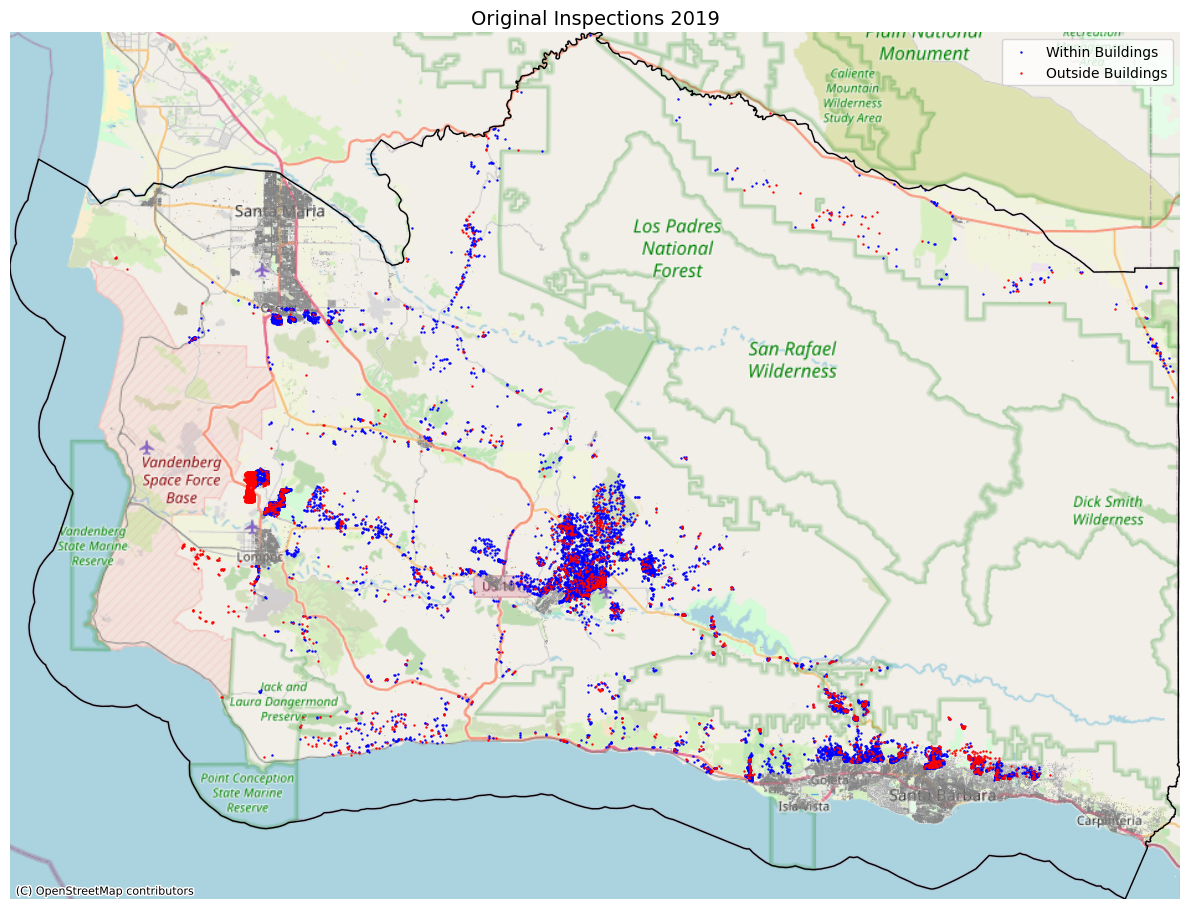

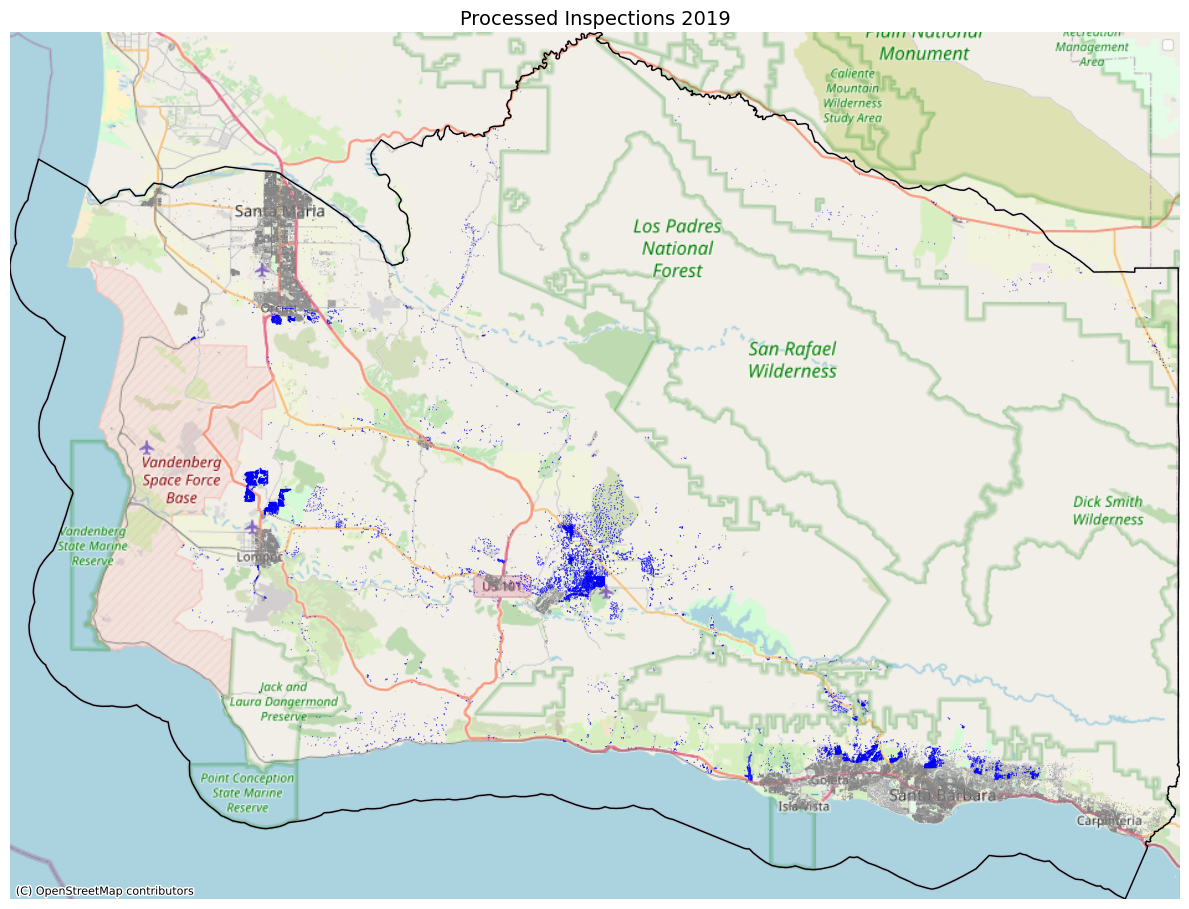

In [12]:
def plot_inspection_processing_comparison(
    year, buildings, processed_inspections_dict, sb_county=None
):
    """
    Plot comparison using pre-processed inspection data

    Parameters:
    -----------
    year : int
        The year to plot data for
    buildings : GeoDataFrame
        Buildings data for plotting
    processed_inspections_dict : dict
        Dictionary containing processed inspections by year
    sb_county : GeoDataFrame
        Santa Barbara County boundary for setting plot extent
    """
    # Get original inspections within and outside buildings
    inspections_within, inspections_outside = inspections_within_buildings(year)

    # Use pre-processed data instead of reprocessing
    processed_data = processed_inspections_dict[year]

    # Helper function to ensure data is in Web Mercator projection
    def reproject_if_needed(gdf):
        if gdf is None:
            return None
        if gdf.crs.to_string() != "EPSG:3857":
            return gdf.to_crs(epsg=3857)
        return gdf.copy()

    # Reproject all data to Web Mercator (required by contextily)
    buildings_projected = reproject_if_needed(buildings)
    inspections_within_projected = reproject_if_needed(inspections_within)
    inspections_outside_projected = reproject_if_needed(inspections_outside)
    sb_county_projected = reproject_if_needed(sb_county)
    processed_data_projected = reproject_if_needed(processed_data)

    # Get map extent from county boundary
    minx, miny, maxx, maxy = sb_county_projected.total_bounds

    # Helper function to set up a basic map
    def setup_map(title):
        fig, ax = plt.subplots(figsize=(12, 10))
        ax.set_xlim(minx, maxx)
        ax.set_ylim(miny, maxy)

        # Plot county boundary and buildings
        sb_county_projected.boundary.plot(ax=ax, color="black", linewidth=1)
        buildings_projected.plot(
            ax=ax, color="lightgray", alpha=0.5, edgecolor="gray", linewidth=0.3
        )

        # Add basemap
        ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

        # Set title and remove axes
        ax.set_title(title, fontsize=14)
        ax.axis("off")

        return fig, ax

    # Create first figure - original inspections
    fig1, ax1 = setup_map(f"Original Inspections {year}")

    # Plot original inspections
    inspections_within_projected.plot(
        ax=ax1, color="blue", markersize=0.5, label="Within Buildings"
    )
    inspections_outside_projected.plot(
        ax=ax1, color="red", markersize=0.5, label="Outside Buildings"
    )
    ax1.legend(loc="upper right")
    fig1.tight_layout()

    # Create second figure - processed inspections
    fig2, ax2 = setup_map(f"Processed Inspections {year}")

    # Plot processed data by geometry type
    if not processed_data_projected.empty:
        # More concise way to handle different geometry types
        for geom_type, color, label in [
            ("Point", "blue", "Point Geometries"),
            (["Polygon", "MultiPolygon"], "blue", "Polygon Geometries"),
        ]:
            # Filter by geometry type(s)
            if isinstance(geom_type, list):
                subset = processed_data_projected[
                    processed_data_projected.geometry.type.isin(geom_type)
                ]
                alpha, linewidth = 0.6, 0.7  # Polygon styling
            else:
                subset = processed_data_projected[
                    processed_data_projected.geometry.type == geom_type
                ]
                alpha, linewidth = 1.0, 0  # Point styling

            if not subset.empty:
                subset.plot(
                    ax=ax2,
                    color=color,
                    alpha=alpha,
                    edgecolor=color if linewidth > 0 else None,
                    linewidth=linewidth,
                    markersize=5 if geom_type == "Point" else None,
                    label=label,
                )

    ax2.legend(loc="upper right")
    fig2.tight_layout()

    return fig1, ax1, fig2, ax2


# Plot for 2019
year = 2019
fig1, ax1, fig2, ax2 = plot_inspection_processing_comparison(
    year, buildings, processed_inspections, sb_county=sb_county
)
plt.show()

Pre-processing data for year 2019...


Data pre-processing complete!
Saving GIF...


/tmp/ipykernel_3450208/254696588.py:102: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="upper right", markerscale=2)
/tmp/ipykernel_3450208/254696588.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right", markerscale=2)
/tmp/ipykernel_3450208/254696588.py:102: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="upper right", markerscale=2)
/tmp/ipykernel_3450208/254696588.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is calle

GIF saved as 'nspections_to_buildings_2019.gif'


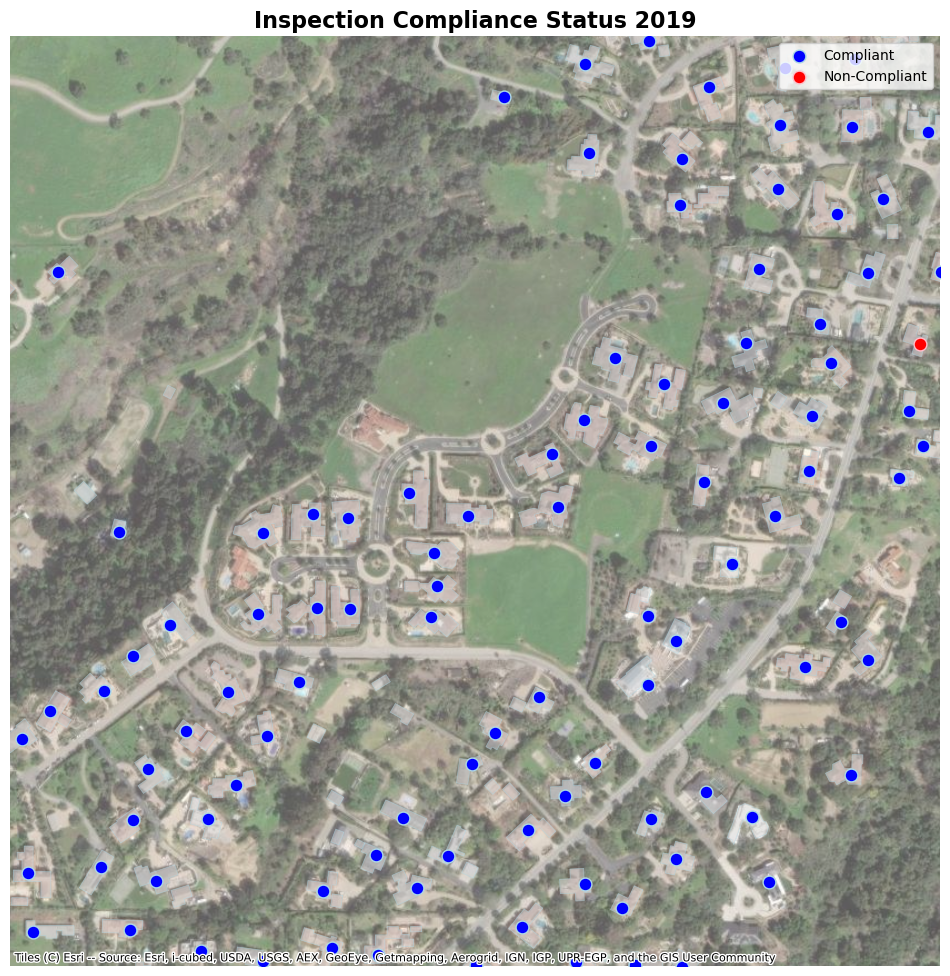

In [15]:
def create_inspection_comparison_gif(
    year,
    buildings,
    processed_inspections_dict,
    sb_county=None,
    xlim=(-13334600, -13333600),  
    ylim=(4090600, 4091600),
):
    """
    Create an animated GIF that flips between two plot types for a single year:
    1. Processed inspections with buildings (zoomed in)
    2. Inspections by compliance status (zoomed in)
    """
    
    # Helper function to ensure data is in Web Mercator projection
    def reproject_if_needed(gdf):
        if gdf is None or gdf.empty:
            return gdf
        if gdf.crs.to_string() != "EPSG:3857":
            return gdf.to_crs(epsg=3857)
        return gdf.copy()

    # PRE-PROCESS DATA ONCE for the single year
    buildings_projected = reproject_if_needed(buildings)
    
    print(f"Pre-processing data for year {year}...")
    
    # Process inspections data for the single year
    processed_data_projected = reproject_if_needed(processed_inspections_dict[year])
    
    # Process compliance data for the single year
    inspections_within, inspections_outside = inspections_within_buildings(year)
    all_inspections = pd.concat([inspections_within, inspections_outside])
    all_inspections_projected = reproject_if_needed(all_inspections)
    
    print("Data pre-processing complete!")
    
    # Create figure with single subplot
    fig, ax = plt.subplots(figsize=(12, 10))
    fig.subplots_adjust(left=0.02, right=0.98, top=0.95, bottom=0.02)

    def animate(frame):
        """Animation function that flips between plot types"""
        # Clear axis
        ax.clear()
        
        # Helper function to set up a basic map with satellite tiles
        def setup_map(title):
            ax.set_xlim(xlim)
            ax.set_ylim(ylim)

            # Add satellite basemap with transparency
            ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery, alpha=0.7)

            # Plot buildings with light blue outline
            buildings_projected.plot(
                ax=ax, 
                color="lightgray", 
                alpha=0.5, 
                edgecolor="lightblue",
                linewidth=0.5
            )

            ax.set_title(title, fontsize=16, fontweight="bold")
            ax.axis("off")

        # Determine which plot to show based on frame number
        # Frame 0 = Processed Inspections, Frame 1 = Compliance Status
        if frame % 2 == 0:
            # Show processed inspections
            setup_map(f"Processed Inspections {year}")

            for geom_type, color, label in [
                ("Point", "blue", "Point Geometries"),
                (["Polygon", "MultiPolygon"], "blue", "Polygon Geometries"),
            ]:
                if isinstance(geom_type, list):
                    subset = processed_data_projected[
                        processed_data_projected.geometry.type.isin(geom_type)
                    ]
                    alpha, linewidth = 1.0, 1.0
                    edgecolor = "lightblue" 
                else:
                    subset = processed_data_projected[
                        processed_data_projected.geometry.type == geom_type
                    ]
                    alpha, linewidth = 1.0, 1.0
                    edgecolor = "lightblue" 

                if not subset.empty:
                    subset.plot(
                        ax=ax,
                        color=color,
                        alpha=alpha,
                        edgecolor=edgecolor,
                        linewidth=linewidth,
                        markersize=12 if geom_type == "Point" else None,
                        label=label,
                    )

            # Add legend
            ax.legend(loc="upper right", markerscale=2)

        else:
            # Show compliance status
            setup_map(f"Inspection Compliance Status {year}")

            if "status" in all_inspections_projected.columns:
                color_dict = {
                    "Compliant": {"color": "blue", "edgecolor": "lightblue"},
                    "Non-Compliant": {"color": "red", "edgecolor": "pink"} 
                }
                
                for status, style in color_dict.items():
                    subset = all_inspections_projected[
                        all_inspections_projected["status"] == status
                    ]
                    if not subset.empty:
                        subset.plot(
                            ax=ax, 
                            color=style["color"], 
                            edgecolor=style["edgecolor"],
                            linewidth=1,
                            markersize=85,
                            alpha=1.0,
                            label=status
                        )

            # Add legend
            ax.legend(loc="upper right", markerscale=1)

    # Create animation with 2 frames that repeat
    anim = animation.FuncAnimation(
        fig,
        animate,
        frames=2, 
        interval=700, 
        repeat=True,
        blit=False,
    )

    # Save as GIF with optimized settings
    print("Saving GIF...")
    anim.save(
        f"/capstone/wildfire_prep/leilanie/data-preparation/figures/inspections_to_buildings_{year}.gif",
        writer="pillow",
        fps=0.5,
        dpi=100,
        savefig_kwargs={'bbox_inches': 'tight', 'pad_inches': 0.1}
    )

    print(f"GIF saved as 'nspections_to_buildings_{year}.gif'")

    # Show the animation
    plt.show()

    return anim


# Create the animated GIF for 2019
year = 2019
animation_obj = create_inspection_comparison_gif(
    year,
    buildings,
    processed_inspections,
    sb_county=sb_county,
    xlim=(-13334600, -13333600), 
    ylim=(4090600, 4091600),
)